# Thermal Decay in a 1D Pore

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi as π
from pimcscripts import pimchelp
from collections import defaultdict
from dgutils import colors as colortools
import matplotlib.transforms as mtransforms

%config InlineBackend.figure_format = 'svg'
%matplotlib inline

# plot style
plot_style = {'aps': '../include/aps.mplstyle', 'notebook': '../include/notebook.mplstyle'}
plt.style.reload_library()
plt.style.use(plot_style['notebook'])

figsize = plt.rcParams['figure.figsize']

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
ρ_col = [colors[0], colors[1], colors[2], colors[3], colors[6], colors[8]]
T_col = [colors[3], colors[2], colors[1], colors[0]]
grey = '#4B4B4B'

In [2]:
%load_ext autoreload
%autoreload 2
import hg_utils
from hg_utils import lab, Tlab, leg_lab

## Simulation Parameters

In [3]:
R = 2.9
# we have different pinches for different total radii
if np.isclose(R,2.9):
    ΔR = [0.0,1.0]
    T = [0.5,1.0,1.5,2.0]
else:
    ΔR = [0.0,2.0,3.0,4.0]
    T = [2.0]

w = 3.0
L = 100
sim_params = {'canonical':False,'μ':-7.2, 'L':L, 'τ':0.004}

## Load the Seed-Averaged Values of the 1D Density in the Core

In [4]:
reduce_params = {'reduce':'T', 'L':100, 'μ':-7.2}

ρ_1d_qmc = {}
ρₒ = {}
est_qmc = {}
ρ_radial_qmc = {}

for cΔR in ΔR:
    ρ_1d_qmc[lab(cΔR)] = pimchelp.PIMCResults(pimchelp.get_reduce_name(**reduce_params, base_dir=hg_utils.base_dir(cΔR,R=R),
                                                                       estimator='linedensity'))
    est_qmc[lab(cΔR)] = pimchelp.PIMCResults(pimchelp.get_reduce_name(**reduce_params, base_dir=hg_utils.base_dir(cΔR,R=R),
                                                                       estimator='estimator'))

    ρ_radial_qmc[lab(cΔR)] = pimchelp.PIMCResults(pimchelp.get_reduce_name(**reduce_params, base_dir=hg_utils.base_dir(cΔR,R=R,cylinder=False),
                                                                       estimator='radial'))

    reduce_par = ρ_1d_qmc[lab(cΔR)].params[0]

    # they all share a common first axis, we shift by L/2
    x = np.append(ρ_1d_qmc[lab(0.0)].x(reduce_par) - L/2,L/2)

    for iT,cT in enumerate(T):
        ρₒ[Tlab(cΔR,cT)] = est_qmc[lab(cΔR)].data['N'][iT]/L

## For the pinched pore we investigate at a density cut

This will be used later when looking at temperature dependence

In [5]:
ρ_3d = {}
num_grid_sep = {}
δ = {}

cT = 2.0 # this is the only temperature we have position data at

for cΔR in ΔR:
    ρ_data = np.load(f'{hg_utils.base_dir(cΔR,cylinder=False, R=R)}/gce-position-{lab(cΔR)}-T_eq_{cT:05.2f}.npz')
    ρ_3d[Tlab(cΔR,cT)] = ρ_data['ρ']
    δ[Tlab(cΔR,cT)] = ρ_data['δ']
    num_grid_sep[Tlab(cΔR,cT)] = int(ρ_data['num_grid_sep'])

mid_idx = int(num_grid_sep[Tlab(cΔR,cT)]/2)

1.13178587


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Font family ['Helvetica Neue'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Helvetica Neue'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Helvetica Neue'] not found. Falling back to DejaVu Sans.


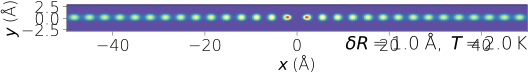

In [6]:
def plot_pore_cut(_ax, cΔR, cT,x_cut, vmax='None', z_ave=False):  

    if vmax == 'None':
        vmax = np.max(ρ_3d[Tlab(cΔR,cT)][:,x_cut,:])

    if not z_ave:
        _ρ_3d = ρ_3d[Tlab(cΔR,cT)][:,x_cut,:]
    else:
        _ρ_3d = np.average(ρ_3d[Tlab(cΔR,cT)],axis=1)

    print(np.max(_ρ_3d))
    im = _ax.imshow(_ρ_3d, extent=[-L/2,L/2,-R,R],cmap='Spectral_r', vmin=0.01, vmax=vmax, rasterized=True)
    _ax.text(1.0, -0.1, leg_lab(cΔR) + f'$,\\; T= {cT}\\, \\mathrm{{K}}$', 
             transform=_ax.transAxes, ha='right', va='top')

    _ax.set_xlabel(r'$x\; (\rm \AA)$')
    _ax.set_ylabel(r'$y\; (\rm \AA)$')
    return _ax,im

cΔR = 1.0
cT = 2.0
plt.style.reload_library()
with plt.style.context(plot_style['notebook']):
    fig,ax = plt.subplots(figsize=(8,4))
    plot_pore_cut(ax,cΔR,cT,mid_idx, vmax=1.15)

## Average the $x<0$ data with $x>0$ data

Here we leverage the fact that we have reflection symmetry around the pinch to improve statistics

In [7]:
start = int((len(x)-1)/2)
end = len(x)-1

idx_pos = range(start,end-1)
idx_neg = range(start-1,0,-1)

ρ̄_1d = {}
Δρ̄_1d = {}
for cT in T:
    for cΔR in ΔR:
        _x,_ρ,_Δρ = ρ_1d_qmc[lab(cΔR)].epdata_byval(cT)
        
        ρ̄_1d[Tlab(cΔR,cT)] = np.append(np.copy(_ρ),_ρ[0])
    
        ρ̄_1d[Tlab(cΔR,cT)][idx_neg] = 0.5*(_ρ[idx_pos] + _ρ[idx_neg])
        ρ̄_1d[Tlab(cΔR,cT)][idx_pos] = 0.5*(_ρ[idx_pos] + _ρ[idx_neg])
        
        Δρ̄_1d[Tlab(cΔR,cT)] = np.append(np.copy(_Δρ),_Δρ[0])
        Δρ̄_1d[Tlab(cΔR,cT)][idx_neg] = 0.5*np.sqrt(_Δρ[idx_pos]**2 + _Δρ[idx_neg]**2) 
        Δρ̄_1d[Tlab(cΔR,cT)][idx_pos] = 0.5*np.sqrt(_Δρ[idx_pos]**2 + _Δρ[idx_neg]**2)

## Extract the maxima and minima

In [8]:
from scipy.signal import argrelmax,argrelmin

ρ_max_arg = defaultdict(list)
ρ_min_arg = defaultdict(list)

# This is the region where we assume high-energy microscopic details are occurring. 
x_mask_in = np.where(np.abs(x)<=2*w+1)[0]

for cΔR in ΔR:
    for iT,cT in enumerate(T):

        # use mirror symmetry
        _x,_ρ,_Δρ = x,ρ̄_1d[Tlab(cΔR,cT)],Δρ̄_1d[Tlab(cΔR,cT)]
    
        idxs = list(range(x_mask_in[0]+1)) + list(range(x_mask_in[-1]+1,len(x)))
        max_arg = argrelmax(_ρ)[0]
        min_arg = argrelmin(_ρ)[0]
    
        x_cut_indices = x_mask_in
        
        ρ_max_arg[Tlab(cΔR,cT)] = [carg for carg in max_arg if carg not in x_cut_indices]
        ρ_min_arg[Tlab(cΔR,cT)] = [carg for carg in min_arg if carg not in x_cut_indices]

## Explore any possibile asymmetry of the decay

-2.948078781095376e-11


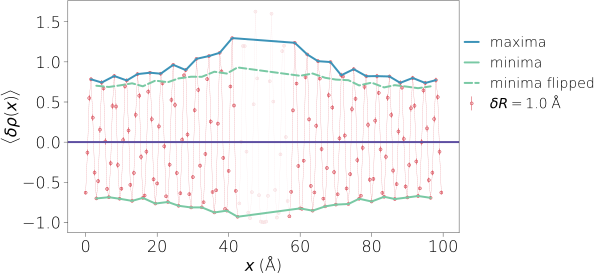

In [9]:
cΔR = 1.0
cT = 2.0
with plt.style.context(plot_style['notebook']):
    figsize = plt.rcParams['figure.figsize']
    fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True, sharey=True, figsize=(figsize[0],figsize[1]))
    
    _x,_ρ,_Δρ =  ρ_1d_qmc[lab(cΔR)].epdata_byval(cT) 
    
    _ρ,_Δρ = hg_utils.shifted_ave(_ρ,_Δρ,ρₒ[Tlab(cΔR,cT)],np.zeros_like(_ρ))
    
    print(np.average(_ρ))
    
    ax = hg_utils.plot_single_ρ(ax,_x,_ρ,_Δρ,x_mask_in,cΔR,ρ_col[-1])
    ax.set_ylabel(r'$\langle \delta \rho(x) \rangle$');

    ax.axhline(y=0)
    ax.plot(_x[ρ_max_arg[Tlab(cΔR,cT)]],_ρ[ρ_max_arg[Tlab(cΔR,cT)]],'-', color=colors[1], label='maxima')
    ax.plot(_x[ρ_min_arg[Tlab(cΔR,cT)]],_ρ[ρ_min_arg[Tlab(cΔR,cT)]],'-', color=colors[2], label='minima')
    ax.plot(_x[ρ_min_arg[Tlab(cΔR,cT)]],-_ρ[ρ_min_arg[Tlab(cΔR,cT)]],'--', color=colors[2], label='minima flipped')

    ax.legend(loc=(1,0.5))

## Explanation / Understanding

I think there are two different things at play here.  

- The fact that the supression of a particle at $x=0$ at the pinch causes the two large peaks and thus breaks the symmetry in the y-axis.
- The possibility of a pure (non-oscillatory) power-law decay stronger than the oscillatory one.

We can address this by performing a half-period differencing that suppresses the trend, but keeps the cosine.

In [10]:
def shift_interp(x, y, shift):
    """Return y(x+shift) via linear interpolation. NaN outside original x-range."""
    return np.interp(x + shift, x, y, period=L)

def half_period_differencing(x, y, half_shift,x_mask):
    """
    half-period differencing
      diff_fwd(x) = y(x) - y(x+half_shift)
      osc_fwd(x)  = 0.5*diff_fwd(x)

    Also return a 'symmetric' variant that reduces trend leakage:
      osc_sym(x) = 0.5*( y(x) - 0.5*(y(x+Δ)+y(x-Δ)) )
    """
    yp = shift_interp(x, y, +half_shift)
    ym = shift_interp(x, y, -half_shift)

    diff_fwd = y - yp
    osc_fwd = 0.5 * diff_fwd
    osc_sym = 0.5 * (y - 0.5*(yp + ym))

    # we don't want to replace anything inside the "masked" short-distance cutoff region
    osc_fwd[x_mask] = y[x_mask] - np.average(y)
    osc_sym[x_mask] = y[x_mask] - np.average(y)

    return diff_fwd, osc_fwd, osc_sym

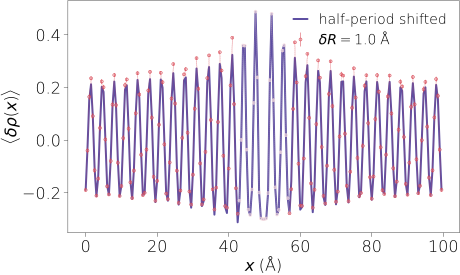

In [11]:
cΔR = 1.0
cT = 2.0
half_period = 1.0 / ρₒ[Tlab(cΔR,cT)] / 2.0

with plt.style.context(plot_style['notebook']):
    figsize = plt.rcParams['figure.figsize']
    fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True, sharey=True, figsize=(figsize[0],figsize[1]))
    
    _x,_ρ,_Δρ = ρ_1d_qmc[lab(cΔR)].epdata_byval(cT)
    
    diff, osc, osc_sym = half_period_differencing(_x,_ρ,half_period,x_mask_in)
    plt.plot(_x,osc_sym, zorder=-10, label='half-period shifted')

    ax = hg_utils.plot_single_ρ(ax,_x,_ρ-ρₒ[Tlab(cΔR,cT)],_Δρ,x_mask_in,cΔR,ρ_col[-1])
    ax.set_ylabel(r'$\langle \delta \rho(x) \rangle$');


    ax.legend()  

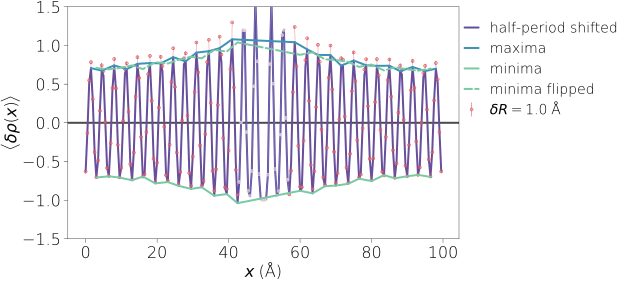

In [12]:
cΔR = 1.0
cT = 2.0
with plt.style.context(plot_style['notebook']):
    figsize = plt.rcParams['figure.figsize']
    fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True, sharey=True, figsize=(figsize[0],figsize[1]))
    
    _x,_ρ,_Δρ =  ρ_1d_qmc[lab(cΔR)].epdata_byval(cT) 
    _ρ,_Δρ = hg_utils.shifted_ave(_ρ,_Δρ,ρₒ[Tlab(cΔR,cT)],np.zeros_like(_ρ))
    
    ax = hg_utils.plot_single_ρ(ax,_x,_ρ,_Δρ,x_mask_in,cΔR,ρ_col[-1])
    ax.axhline(y=0, color=grey, zorder=-100)

    diff, osc, osc_sym = half_period_differencing(_x,_ρ,half_period,x_mask_in)
    plt.plot(_x,osc_sym, zorder=-10, label='half-period shifted')
    ax.plot(_x[ρ_max_arg[Tlab(cΔR,cT)]],osc_sym[ρ_max_arg[Tlab(cΔR,cT)]],'-', color=colors[1], label='maxima')
    ax.plot(_x[ρ_min_arg[Tlab(cΔR,cT)]],osc_sym[ρ_min_arg[Tlab(cΔR,cT)]],'-', color=colors[2], label='minima')
    ax.plot(_x[ρ_min_arg[Tlab(cΔR,cT)]],-osc_sym[ρ_min_arg[Tlab(cΔR,cT)]],'--', color=colors[2], label='minima flipped')

    ax.legend(loc=(1,0.5))
    ax.set_ylim(-1.5,1.5)
    ax.set_ylabel(r'$\langle \delta \rho(x) \rangle$');

    #ax.set_xlim(50,100)

## It worked!

Outside the masked region close to the pinch, now the data is symmetric.

In [13]:
def plot_temp_dependence(_ax):

    for iT,cT in enumerate(T):
        _x,_ρ,_Δρ = x,ρ̄_1d[Tlab(cΔR,cT)],Δρ̄_1d[Tlab(cΔR,cT)]

        # we shift and rescale then perform the half-period differencing
        _ρ,_Δρ = hg_utils.shifted_ave(_ρ,_Δρ,ρₒ[Tlab(cΔR,cT)],np.zeros_like(_ρ))
        diff, osc, osc_sym = half_period_differencing(_x,_ρ,half_period,x_mask_in)

        _ax = hg_utils.plot_single_ρ(_ax,_x,osc_sym,_Δρ,x_mask_in,cΔR,T_col[iT],
                                    label=f'$T= {cT}\, \\mathrm{{K}}$', interp=True);
        _ax.legend(ncols=2)
        _ax.set_ylabel(r'$\langle \delta \rho(x) \rangle/\rho_0$');
        _ax.text(1.0, 0.0, leg_lab(cΔR), 
             transform=_ax.transAxes, ha='right', va='bottom')

    _ax.set_xlim(0,50.25)

    return _ax

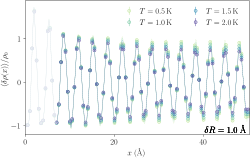

In [14]:
cΔR = 1.0
with plt.style.context(plot_style['aps']):
    figsize = plt.rcParams['figure.figsize']
    fig,ax = plt.subplots()

    ax = plot_temp_dependence(ax)
    plt.savefig(f'../figures/rho_vs_x_T_dependence_dR_eq_{cΔR:3.1f}.pdf')
    plt.savefig(f'../figures/rho_vs_x_T_dependence_dR_eq_{cΔR:3.1f}.svg')

## Make a combined figure including the full density

0.316635884
1.13178587


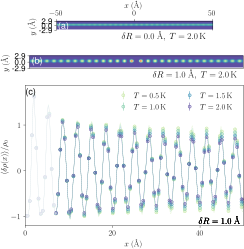

In [32]:
import matplotlib.patheffects as pe
plt.style.reload_library()
with plt.style.context(plot_style['aps']):
    
    figsize = plt.rcParams['figure.figsize']
    fig = plt.figure(figsize=(figsize[0],1.65*figsize[1]), constrained_layout=True)
    cut1_fig,cut2_fig,temp_fig = fig.subfigures(nrows=3,ncols=1, height_ratios=[1.1,0.9,4],hspace=0.0)

    # the density cut for δR = 0 ----------------------------------------------------------
    ax_cut1 = cut1_fig.subplots()
    plot_pore_cut(ax_cut1,0.0,2.0,mid_idx,vmax=1.15)

    # put the x-axis on top
    ax_cut1.xaxis.set_label_position('top')
    ax_cut1.xaxis.tick_top()
    ax_cut1.tick_params(axis='x', bottom=False, top=True)
    ax_cut1.spines['bottom'].set_visible(False)

    ## make a custom y-axis
    ax_cut1.set_yticks([-R, 0.0, R])
    ax_cut1.set_yticklabels([-R, 0.0, R])

    # the density cut for δR = 1 ----------------------------------------------------------
    ax_cut2 = cut2_fig.subplots()
    plot_pore_cut(ax_cut2,1.0,2.0,mid_idx,vmax=1.15)
    ax_cut2.get_xaxis().set_visible(False)
    
    ## make a custom y-axis
    ax_cut2.set_yticks([-R, 0.0, R])
    ax_cut2.set_yticklabels([-R, 0.0, R])
    
    # temperature dependence of the density
    ax_temp = temp_fig.subplots()
    ax_temp = plot_temp_dependence(ax_temp)

    ax_temp.set_xlim(0,49.9)

    ## Add labels
    shadow1px = [pe.Stroke(linewidth=1, foreground="black"), pe.Normal()]
    drop_shadow = [pe.SimpleLineShadow(offset=(2, -5), shadow_color="black", alpha=0), pe.Normal()]

    ax_cut1.text(0.01, 0.90, "(a)", transform=ax_cut1.transAxes, ha='left', va='top', color='w', fontweight="bold")
    ax_cut2.text(0.01, 0.90, "(b)", transform=ax_cut2.transAxes, ha='left', va='top', color='w', fontweight="bold")
    ax_temp.text(0.00, 0.98, "(c)", transform=ax_temp.transAxes, ha='left', va='top')

    
    plt.savefig(f'../figures/rho_vs_x_T_dependence_dR_eq_{cΔR:3.1f}_w_density_cut.pdf')
    plt.savefig(f'../figures/rho_vs_x_T_dependence_dR_eq_{cΔR:3.1f}_w_density_cut.png')

## Now let's try to explore the thermal decay predicted by LL theory.

Here the Luttinger parameters are known from previous QMC simulations. 

| Radius $R$ (Å) | Luttinger Velocity $v$ (Å K) | Luttinger Parameter $K$ |
|------------------|-------------------------------|---------------------------|
| 0.0              | 75(1)                         | 6.4(3)                    |
| 2.9              | 70(3)                         | 6.0(2)                    |
| 12.0             | 42(2)                         | 1.3(1)                    |


See, e.g. [A. D. Maestro, Int J Mod Phys B 26, 1244002 (2012).](https://www.worldscientific.com/doi/abs/10.1142/S021797921244002X)

In [16]:
import mpmath
def thermal_decay(x,A,T,L,ρₒ):
    
    # these are known from previous QMC work
    K = 6.0
    a = 1.0/ρₒ  
    v = 70

    q = np.exp(-π * v / (L * T))
    α = a*K/(2.0*np.pi)

    # ensure we can handle numpy arrays
    def single_val(_x):
        return A * α**(1.0/K) * (π*mpmath.jtheta(1,0,q,1)/(L*mpmath.jtheta(1, π*(_x+α)/ L, q))) ** (1.0/K)

    # vectorize over numpy array
    f_vec = np.vectorize(single_val, otypes=[float])
    return f_vec(x)

In [17]:
from lmfit import minimize, Parameters

def LL_friedel(params,x_):
    LL_decay = -thermal_decay(x_,params['A'].value,params['T'].value,params['L'].value,params['ρₒ'].value)
    return  LL_decay * np.cos(2*π*params['ρₒ'].value*x_ + params['ϕ'].value)

def get_fit(x,y,A,ϕ,T,L,ρₒ):
    fit_params = Parameters()
    fit_params.add('A', value=A, min=0.5, max=2.0, vary=False)
    fit_params.add('ϕ', value=ϕ, min=-π, max=π, vary=True)
    fit_params.add('T', value=T, vary=False)
    fit_params.add('L', value=L, vary=False)
    fit_params.add('ρₒ', value=ρₒ, vary=False)
    
    def fss_residual(params, x_, y_):
        return LL_friedel(params,x_) - y_
        
    fit = minimize(fss_residual, fit_params, args=(x,y))
    
    return lambda x: LL_friedel(fit.params,x),fit

## Luttinger Liquid Prediction

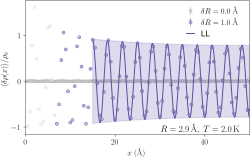

In [18]:
cΔR = 1.0

with plt.style.context(plot_style['aps']):
    figsize = plt.rcParams['figure.figsize']
    fig,ax = plt.subplots(nrows=1,ncols=1,sharex=True, sharey=True, figsize=(figsize[0],figsize[1]))

    cT = 2.0
    iT = T.index(cT)

    _x,_ρ,_Δρ = x,ρ̄_1d[Tlab(0.0,0.5)],Δρ̄_1d[Tlab(0.0,0.5)]
    ax = hg_utils.plot_single_ρ(ax,_x,_ρ,_Δρ,range(0,1),0.0,colortools.get_alpha_hex(grey,0.5),
                                shift=True, ave_ρ=ρₒ[Tlab(0.0,cT)], line=False)
    
    # set everything to the back
    for ln in ax.lines:
        ln.set_zorder(-1000)
    for c in ax.collections:
        c.set_zorder(-1000)
    
    _x,_ρ,_Δρ = x,ρ̄_1d[Tlab(cΔR,cT)],Δρ̄_1d[Tlab(cΔR,cT)]
    _ρ,_Δρ = hg_utils.shifted_ave(_ρ,_Δρ,ρₒ[Tlab(cΔR,cT)],np.zeros_like(_ρ))

    diff, osc, osc_sym = half_period_differencing(_x,_ρ,half_period,x_mask_in)

    start_fit_idx = ρ_max_arg[Tlab(cΔR,cT)][-11]
    fit_LL,fit = get_fit(_x[start_fit_idx:],osc_sym[start_fit_idx:],1.25,0.0,cT,L,ρₒ[Tlab(cΔR,cT)])

    ax = hg_utils.plot_single_ρ(ax,_x,osc_sym,_Δρ,x_mask_in,cΔR,T_col[iT], line=False, interp=False)    
    ax.set_ylabel(r'$\langle \delta \rho(x) \rangle / \rho_0$');

    # now try for the thermal decay
    fit_x = np.linspace(_x[start_fit_idx],L/2,1000)
    upper_env = thermal_decay(fit_x,fit.params['A'].value,cT,L,ρₒ[Tlab(cΔR,cT)])

    ax.plot(fit_x,LL_friedel(fit.params,fit_x), lw=1, color=T_col[iT], label='LL', zorder=-10)
    ax.fill_between(fit_x,-upper_env,y2=upper_env, color=T_col[iT], alpha=0.2, zorder=-2)

    # temperature label
    trans = mtransforms.ScaledTranslation(1/72, -9/72, fig.dpi_scale_trans)
    ax.text(0.98, 0.075, f'$R=2.9\\, \\mathrm{{\\AA}},\\; T= {cT}\\, \\mathrm{{K}}$', transform=ax.transAxes + trans, ha='right', va='bottom')

    # reorder legend
    handles, labels = ax.get_legend_handles_labels()
    order = [1, 2, 0] 
    ax.legend([handles[i] for i in order], [labels[i]  for i in order], ncol=1)

    ax.set_xlim(0,49.9)
    
    plt.savefig(f'../figures/rho_vs_x_LL_envelope_dR_eq_{cΔR:3.1f}_T_eq_{cT:3.1f}.pdf')
    plt.savefig(f'../figures/rho_vs_x_LL_envelope_dR_eq_{cΔR:3.1f}_T_eq_{cT:3.1f}.svg')

In [19]:
fit